# 残差の確認

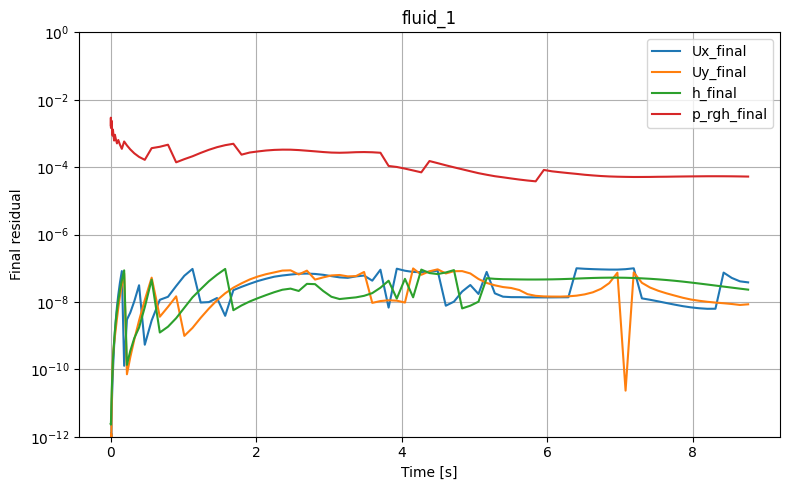

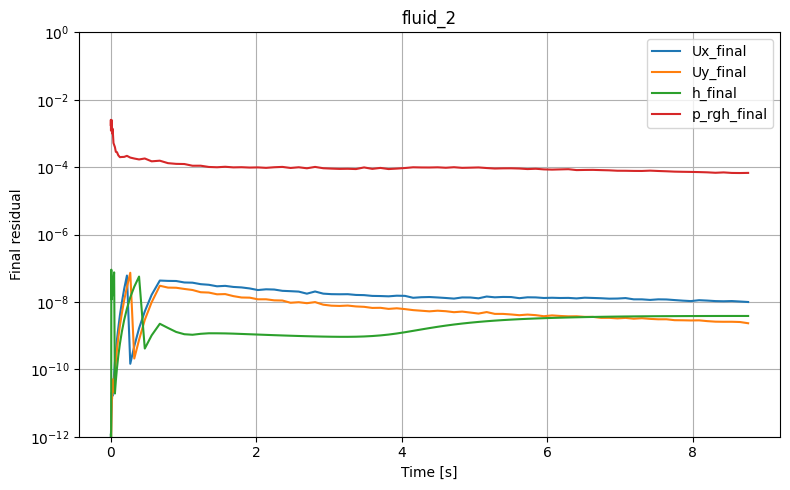

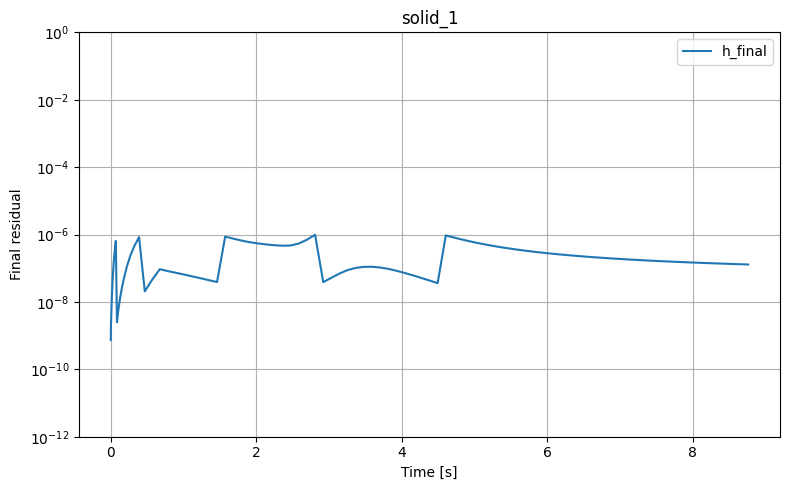

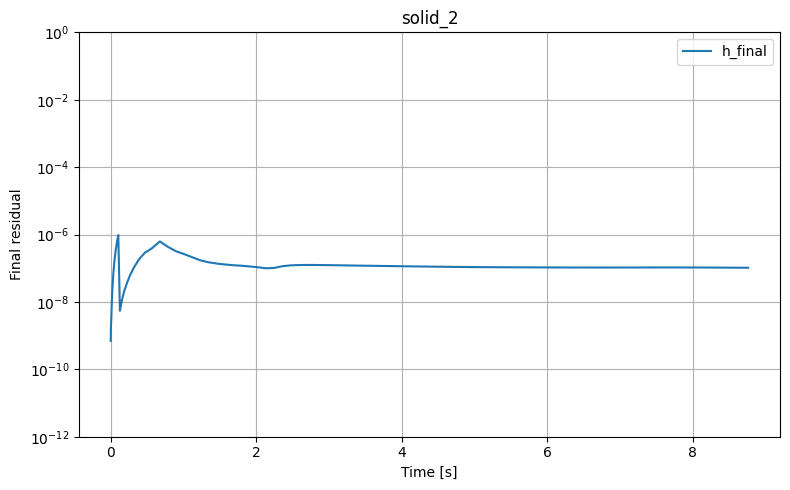

In [12]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_fluid_residual(file_path, label, ymin=1e-12, ymax=1):
    df = pd.read_csv(
        file_path,
        comment="#",
        sep=r"\s+",
        header=None,
        names=[
            "Time",
            "U_solver",
            "Ux_initial",
            "Ux_final",
            "Ux_iters",
            "Uy_initial",
            "Uy_final",
            "Uy_iters",
            "U_converged",
            "h_solver",
            "h_initial",
            "h_final",
            "h_iters",
            "h_converged",
            "p_rgh_solver",
            "p_rgh_initial",
            "p_rgh_final",
            "p_rgh_iters",
            "p_rgh_converged",
        ],
        engine="python"
    )

    plt.figure(figsize=(8, 5))
    plt.plot(df["Time"], df["Ux_final"], label="Ux_final")
    plt.plot(df["Time"], df["Uy_final"], label="Uy_final")
    plt.plot(df["Time"], df["h_final"], label="h_final")
    plt.plot(df["Time"], df["p_rgh_final"], label="p_rgh_final")

    plt.yscale("log")
    plt.ylim(ymin, ymax)
    plt.xlabel("Time [s]")
    plt.ylabel("Final residual")
    plt.title(label)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_solid_residual(file_path, label, ymin=1e-12, ymax=1):
    df = pd.read_csv(
        file_path,
        comment="#",
        sep=r"\s+",
        header=None,
        names=[
            "Time",
            "h_solver",
            "h_initial",
            "h_final",
            "h_iters",
            "h_converged",
        ],
        engine="python"
    )

    plt.figure(figsize=(8, 5))
    plt.plot(df["Time"], df["h_final"], label="h_final")

    plt.yscale("log")
    plt.ylim(ymin, ymax)
    plt.xlabel("Time [s]")
    plt.ylabel("Final residual")
    plt.title(label)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_fluid_residual(
    "postProcessing/fluid_1/residuals_fluid_1/0/solverInfo.dat",
    "fluid_1"
)

plot_fluid_residual(
    "postProcessing/fluid_2/residuals_fluid_2/0/solverInfo.dat",
    "fluid_2"
)

plot_solid_residual(
    "postProcessing/solid_1/residuals_solid_1/0/solverInfo.dat",
    "solid_1"
)

plot_solid_residual(
    "postProcessing/solid_2/residuals_solid_2/0/solverInfo.dat",
    "solid_2"
)

# 熱量の比較

C:\Users\user\AppData\Local\Temp\ipykernel_21664\3877217982.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(
C:\Users\user\AppData\Local\Temp\ipykernel_21664\3877217982.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(


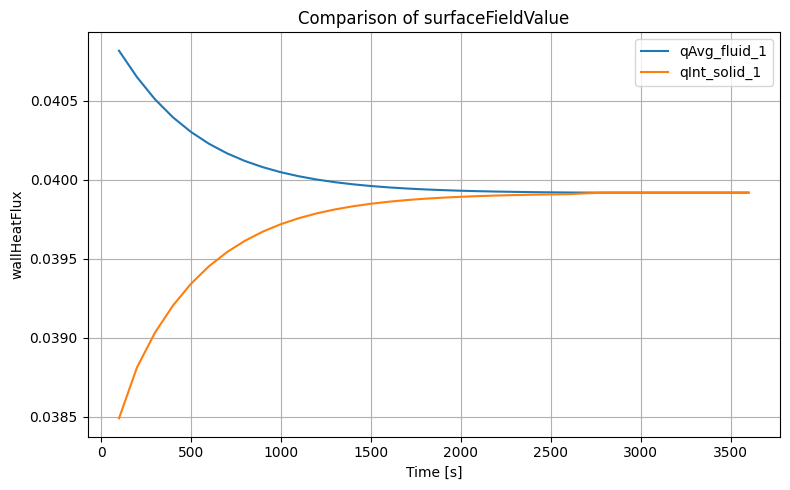

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== 読み込むファイル =====
file1 = "postProcessing/fluid_1/qInt_fluid_1/0/surfaceFieldValue.dat"
file2 = "postProcessing/solid_1/qInt_solid_1/0/surfaceFieldValue.dat"

# ===== データ読み込み関数 =====
def read_surface_field_value(filepath):
    data = pd.read_csv(
        filepath,
        comment="#",          # # で始まる行を無視
        delim_whitespace=True, # 空白・タブ区切り
        header=None,
        names=["Time", "Value"]
    )
    return data

# ===== 読み込み =====
df1 = read_surface_field_value(file1)
df2 = read_surface_field_value(file2)

# ===== グラフ描画 =====
plt.figure(figsize=(8, 5))
plt.plot(df1["Time"], -df1["Value"], label="qAvg_fluid_1")
plt.plot(df2["Time"], df2["Value"], label="qInt_solid_1")

plt.xlabel("Time [s]")
plt.ylabel("wallHeatFlux")
plt.title("Comparison of surfaceFieldValue")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()